In [2]:
!pip install numpy
!pip install pandas
!pip install matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.1 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 22.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 19.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 44.0 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------ --------------------------------- 1/6 [kiwisolver]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [20]:
# CSV 파일 경로
csv_path = r"C:\Users\SSAFY\Desktop\pjt-02\NFLX.csv"

# CSV 파일 읽어오기 (첫 번째, 마지막 열 제외)
df = pd.read_csv(csv_path, usecols=range(5))

# DataFrame 출력
df

,Date,Open,High,Low,Close
0,2018-02-05,262.000000,267.899994,250.029999,254.259995
1,2018-02-06,247.699997,266.700012,245.000000,265.720001
2,2018-02-07,266.579987,272.450012,264.329987,264.559998
3,2018-02-08,267.079987,267.619995,250.000000,250.100006
4,2018-02-09,253.850006,255.800003,236.110001,249.470001
...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006


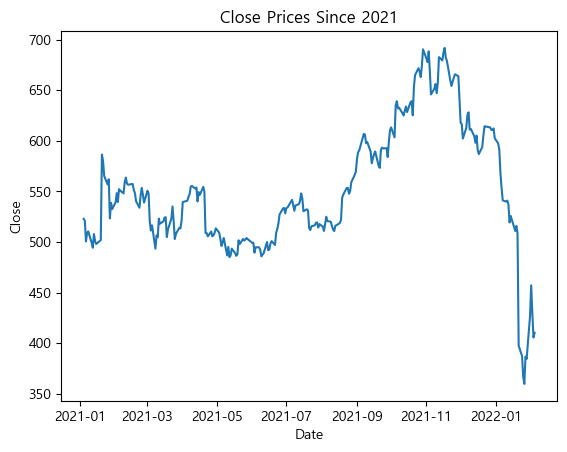

In [22]:
# ① Date 컬럼을 datetime 타입으로 변환 (필요 시)
df["Date"] = pd.to_datetime(df["Date"])

# ② 2021년 1월 1일 이후 데이터만 필터링
df_filtered = df[df["Date"] >= "2021-01-01"]

# ③ 필터링된 데이터로 종가(Close) 그래프 그리기
plt.plot(df_filtered['Date'], df_filtered['Close'])

# 그래프 제목과 레이블 설정
plt.title('Close Prices Since 2021')
plt.xlabel('Date')
plt.ylabel('Close')

# 그래프 출력
plt.show()

In [25]:

# 2021년 1월 1일 이후 데이터 필터링
df_filtered = df[df["Date"] >= "2021-01-01"]

# 종가(Close) 최대값과 최소값 추출
max_close = df_filtered["Close"].max()
min_close = df_filtered["Close"].min()

print(f"최고 종가: {max_close}")
print(f"최저 종가: {min_close}")

최고 종가: 691.690002
최저 종가: 359.700012


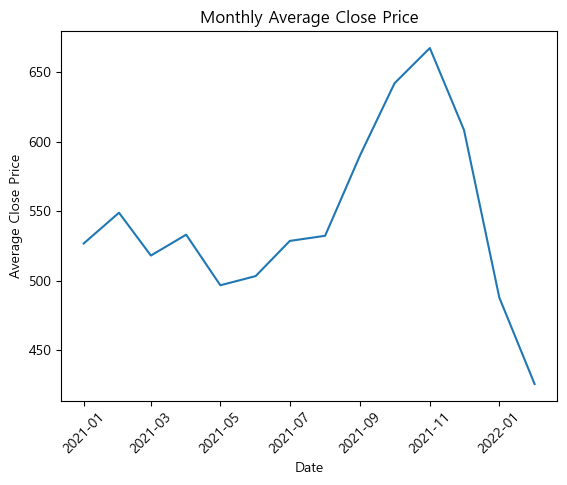

In [29]:

# 2021년 이후 데이터 필터링
df_filtered = df[df["Date"] >= "2021-01-01"]

# 월별 그룹화 위해 YearMonth 컬럼 생성 (Period 타입)
df_filtered['YearMonth'] = df_filtered['Date'].dt.to_period('M')

# 월별 평균 종가 계산
monthly_avg_close = df_filtered.groupby('YearMonth')['Close'].mean().reset_index()

# 그래프용으로 YearMonth를 datetime으로 변환
monthly_avg_close['YearMonth'] = monthly_avg_close['YearMonth'].dt.to_timestamp()

# 그래프 그리기 (marker 삭제)
plt.plot(monthly_avg_close['YearMonth'], monthly_avg_close['Close'])

# 제목 및 레이블 설정
plt.title('Monthly Average Close Price')
plt.xlabel('Date')
plt.ylabel('Average Close Price')

# x축 라벨 각도 조절
plt.xticks(rotation=45)

# 그리드 삭제 (기본적으로 꺼져있지만 확실히 끄려면)
plt.grid(False)

# 그래프 출력
plt.show()

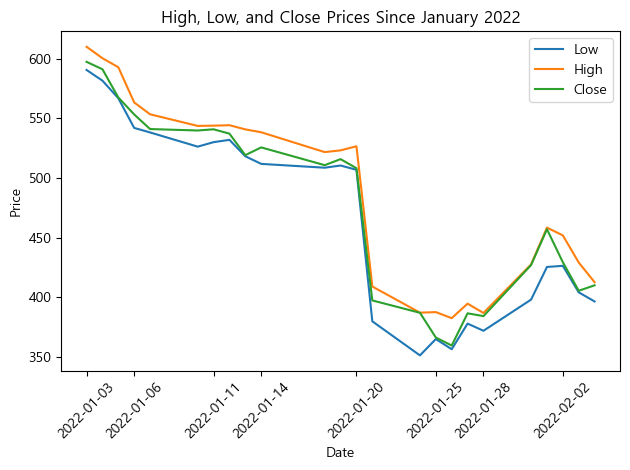

In [39]:
# 1️⃣ 2022년 이후 데이터 필터링
price_after_2022 = df[df["Date"] >= "2022-01-01"].copy()

# 2️⃣ 날짜 기준 정렬
price_after_2022 = price_after_2022.sort_values("Date")

# 3️⃣ x축 눈금 (3개 중 1개만 표시)
x_ticks = price_after_2022["Date"].iloc[::3]

# 4️⃣ 그래프 그리기
plt.plot(price_after_2022["Date"], price_after_2022["Low"], label="Low")
plt.plot(price_after_2022["Date"], price_after_2022["High"], label="High")
plt.plot(price_after_2022["Date"], price_after_2022["Close"], label="Close")

# 5️⃣ 제목 및 축 설정
plt.title("High, Low, and Close Prices Since January 2022")
plt.xlabel("Date")
plt.ylabel("Price")

# 6️⃣ x축 설정
plt.xticks(x_ticks, rotation=45)

# 7️⃣ 범례
plt.legend()

plt.tight_layout()
plt.show()